# Seasonal and Holiday Effects on Gas Demand in Ireland - An Explainable Machine Learning Approach for Human-Centered Insights

## Table of Contents

1. [Introduction](#section_1)
2. [Data Loading and Preprocessing](#section_2)
3. [Feature Engineering](#section_3)
4. [Exploratory Data Analysis (EDA)](#section_4)
5. [Model Building](#section_5)
  - [5.1 Linear Regression](#subsection_5_1)
  - [5.2 SARIMAX](#subsection_5_2)
  - [5.3 Time-Based and Seasonal Interaction Features for Ensemble Models](#subsection_5_3)
  - [5.4 Random Forest](#subsection_5_4)
  - [5.5 Extreme Gradient Boosting - XGBoost](#subsection_5_5)
  - [5.6 Grid Search with Time-Aware Cross-Validation for XGBoost](#subsection_5_6)
6. [Model Evaluation](#section_6)
7. [Explainable AI (XAI)](#section_7)
  - [7.1 TreeExplainer using SHAP](#subsection_7_1)
  - [7.2 SHAP Interaction Plots](#subsection_7_2)
  - [7.3 Partial Dependence Plots - PDP](#subsection_7_3)
  - [7.4 Diverse Counterfactual Explanations - DiCE](#subsection_7_4)
  - [7.5 Explainability Summary: SHAP, PDP, and DiCE](#subsection_7_5)
8. [Conclusion](#section_8)


<a id="section_1"></a>

## 1. Introduction



This project focuses on forecasting daily gas demand in Ireland using machine learning techniques. The objective is to develop interpretable models that can provide insights into the factors influencing gas consumption patterns.

<a id="section_2"></a>
## 2. Data Loading and Preprocessing


We begin by importing the necessary datasets and performing initial preprocessing steps to prepare the data for analysis.

In [1]:
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:
demand_data = pd.read_csv('https://raw.githubusercontent.com/SiddhanthNB/xai-gas-prediction-ireland/main/data/NGSD02.csv')
demand_data.head()

,STATISTIC,Statistic Label,TLIST(D1),Day,C04132V04898,Network Gas Customer Type,UNIT,VALUE
0,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,20,Non-Daily Metered (annual consumption < 5.55 GWh),Gigawatt hours,55.409405
1,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,30,Daily Metered (annual consumption >= 5.55 GWh ...,Gigawatt hours,7.251362
2,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,40,Large Daily Metered (annual metered capacity >...,Gigawatt hours,9.494423
3,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,10,Power Plants,Gigawatt hours,57.062501
4,NGSD02C01,Networked Gas Daily Demand,2018M01D01,2018 January 01,-,All networked gas customers,Gigawatt hours,129.217691


In [3]:
demand_data['Network Gas Customer Type'].value_counts()

,count
Network Gas Customer Type,
Non-Daily Metered (annual consumption < 5.55 GWh),2526
Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),2526
Large Daily Metered (annual metered capacity >= 57.5 GWh),2526
Power Plants,2526
All networked gas customers,2526


In [4]:
demand_data_pivoted = demand_data.pivot(index='Day', columns='Network Gas Customer Type', values='VALUE').reset_index()
demand_data_pivoted['DateTime'] = pd.to_datetime(demand_data_pivoted['Day'], format='%Y %B %d')
demand_data_pivoted = demand_data_pivoted.drop(columns=['Day'])
demand_data_pivoted = demand_data_pivoted.reset_index(drop=True)

demand_data_pivoted.head()

Network Gas Customer Type,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05


In [5]:
demand_data_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 6 columns):
 #   Column                                                         Non-Null Count  Dtype         
---  ------                                                         --------------  -----         
 0   All networked gas customers                                    2526 non-null   float64       
 1   Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)  2526 non-null   float64       
 2   Large Daily Metered (annual metered capacity >= 57.5 GWh)      2526 non-null   float64       
 3   Non-Daily Metered (annual consumption < 5.55 GWh)              2526 non-null   float64       
 4   Power Plants                                                   2526 non-null   float64       
 5   DateTime                                                       2526 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 118.5 KB


In [6]:
supply_data = pd.read_csv('https://raw.githubusercontent.com/SiddhanthNB/xai-gas-prediction-ireland/main/data/NGSD01.csv')
supply_data.head()

,STATISTIC,Statistic Label,TLIST(D1),Day,C04236V05009,Supply Type,UNIT,VALUE
0,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,-,All networked gas supply,Gigawatt hours,129.217691
1,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,10,Networked gas supply - indigenous production,Gigawatt hours,111.682190
2,NGSD01C01,Networked Gas Daily Supply,2018M01D01,2018 January 01,20,Networked gas supply - imports,Gigawatt hours,17.535501
3,NGSD01C01,Networked Gas Daily Supply,2018M01D02,2018 January 02,-,All networked gas supply,Gigawatt hours,132.580714
4,NGSD01C01,Networked Gas Daily Supply,2018M01D02,2018 January 02,10,Networked gas supply - indigenous production,Gigawatt hours,115.101624


In [7]:
supply_data_pivoted = supply_data.pivot(index='Day', columns='Supply Type', values='VALUE').reset_index()
supply_data_pivoted['DateTime'] = pd.to_datetime(supply_data_pivoted['Day'], format='%Y %B %d')
supply_data_pivoted = supply_data_pivoted.drop(columns=['Day'])
supply_data_pivoted = supply_data_pivoted.reset_index(drop=True)

supply_data_pivoted.head()

Supply Type,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production,DateTime
0,146.711805,39.291462,107.420343,2018-04-01
1,165.611510,60.055502,105.556008,2018-04-02
2,167.741525,60.435102,107.306423,2018-04-03
3,173.564111,66.254217,107.309894,2018-04-04
4,144.059799,36.725712,107.334087,2018-04-05


In [8]:
supply_data_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 4 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   All networked gas supply                      2526 non-null   float64       
 1   Networked gas supply - imports                2526 non-null   float64       
 2   Networked gas supply - indigenous production  2526 non-null   float64       
 3   DateTime                                      2526 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3)
memory usage: 79.1 KB


In [9]:
# merge these two dfs

merged_data = pd.merge(demand_data_pivoted, supply_data_pivoted, on='DateTime', how='left')
merged_data.head()

,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01,146.711805,39.291462,107.420343
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02,165.611510,60.055502,105.556008
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03,167.741525,60.435102,107.306423
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04,173.564111,66.254217,107.309894
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05,144.059799,36.725712,107.334087


In [10]:
merged_data['Date'] = merged_data['DateTime'].dt.date.astype('str')
merged_data.head()

,All networked gas customers,Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh),Large Daily Metered (annual metered capacity >= 57.5 GWh),Non-Daily Metered (annual consumption < 5.55 GWh),Power Plants,DateTime,All networked gas supply,Networked gas supply - imports,Networked gas supply - indigenous production,Date
0,146.711805,8.175452,17.881889,50.396686,70.257778,2018-04-01,146.711805,39.291462,107.420343,2018-04-01
1,165.611510,8.847883,16.848860,54.829490,85.085277,2018-04-02,165.611510,60.055502,105.556008,2018-04-02
2,167.741525,9.937754,17.283692,44.896469,95.623610,2018-04-03,167.741525,60.435102,107.306423,2018-04-03
3,173.564111,11.071997,17.966194,55.070364,89.455556,2018-04-04,173.564111,66.254217,107.309894,2018-04-04
4,144.059799,10.560184,18.097663,54.660007,60.741945,2018-04-05,144.059799,36.725712,107.334087,2018-04-05


In [11]:
merged_data = merged_data.rename(columns={
    'DateTime': 'date_time',
    'Date': 'date',
    'All networked gas customers': 'total_demand',
    'Daily Metered (annual consumption >= 5.55 GWh and < 57.5 GWh)': 'small_metered_demand',
    'Large Daily Metered (annual metered capacity >= 57.5 GWh)': 'large_metered_demand',
    'Non-Daily Metered (annual consumption < 5.55 GWh)': 'non_metered_demand',
    'Power Plants': 'power_plant_demand',
    'All networked gas supply': 'total_supply',
    'Networked gas supply - imports': 'imported_supply',
    'Networked gas supply - indigenous production': 'local_supply'
})

merged_data = merged_data[['date_time', 'date', 'imported_supply', 'local_supply', 'total_supply', 'non_metered_demand', 'small_metered_demand', 'large_metered_demand', 'power_plant_demand', 'total_demand']]
merged_data['supply_demand_diff'] = merged_data['total_supply'] - merged_data['total_demand']

merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0


In [12]:
merged_data.describe()

,date_time,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff
count,2526,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000
mean,2021-06-16 12:00:00,98.133096,54.201660,152.334756,31.294291,9.058458,16.164441,95.876216,152.393407,-0.058651
min,2018-01-01 00:00:00,0.121983,0.000000,71.447572,6.534082,4.375607,5.119280,36.554999,71.685350,-0.381877
25%,2019-09-24 06:00:00,73.269391,35.321917,132.635175,12.846622,7.722517,14.847689,78.318750,132.694342,-0.118264
50%,2021-06-16 12:00:00,96.544000,47.090939,151.655414,28.869508,8.835984,16.361759,96.825695,151.754277,0.000000
75%,2023-03-09 18:00:00,120.149258,73.812488,171.018348,47.417615,10.479090,17.771905,113.533403,171.018348,0.000000
max,2024-11-30 00:00:00,223.458938,117.938242,261.326100,97.227563,14.030331,21.967155,167.389168,261.448600,0.000000
std,NaN,35.164032,25.222567,29.642927,18.746416,1.857509,2.376663,24.301787,29.629737,0.076150


In [13]:
merged_data.isna().sum()

,0
date_time,0
date,0
imported_supply,0
local_supply,0
total_supply,0
non_metered_demand,0
small_metered_demand,0
large_metered_demand,0
power_plant_demand,0
total_demand,0


<a id="section_3"></a>
## 3. Feature Engineering

In this section, we create new features that may help improve the model's predictive performance. This includes generating time-based features and encoding categorical variables.

In [14]:
!pip --quiet install meteostat geopandas beautifulsoup4

In [15]:
import requests
import numpy as np
import geopandas as gpd
from bs4 import BeautifulSoup
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Stations, Daily
from sklearn.preprocessing import OneHotEncoder

In [16]:
start_date = merged_data['date_time'].min()
end_date = merged_data['date_time'].max()

In [17]:
stations = Stations()
wind_df = pd.DataFrame()
temparature_df = pd.DataFrame()

ireland_stations = stations.region('IE') # weather stations in ireland region
ireland_stations = ireland_stations.inventory('daily', end_date)

ireland_stations_count = ireland_stations.count()
ireland_stations_all = ireland_stations.fetch(ireland_stations_count)

for id, row in ireland_stations_all.iterrows():
    daily = Daily(id, start_date, end_date)
    daily_data = daily.fetch()
    temparature_df[row['name']] = daily_data['tavg']
    wind_df[row['name']] = daily_data['wspd']

In [18]:
# take only columns which has null percentage less than 10%

null_percentage = wind_df.isnull().mean() * 100
columns_to_keep = null_percentage[null_percentage < 10].index
wind_df = wind_df[columns_to_keep]

null_percentage = temparature_df.isnull().mean() * 100
columns_to_keep = null_percentage[null_percentage < 10].index
temparature_df = temparature_df[columns_to_keep]

# check for null values in both df
print('Null values in temparature_df:')
print(temparature_df.isnull().sum())
print('\n')
print('\nNull values in wind_df:')
print(wind_df.isnull().sum())

Null values in temparature_df:
Valentia Observatory                0
Cork Airport                        0
Johnstown Castle / Ballykilliane    9
Shannon Airport                     0
Casement Aerodrome                  0
Dublin Airport                      0
Connaught Airport                   0
Belmullet                           0
Malin Head                          0
dtype: int64



Null values in wind_df:
Valentia Observatory    31
Cork Airport             0
Shannon Airport          0
Casement Aerodrome       2
Dublin Airport           0
Connaught Airport        8
Belmullet               32
Malin Head              32
dtype: int64


In [19]:
def get_season(datetime):
    month = datetime.month
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'autumn'
    else:
        return np.nan

avg_wind = wind_df.mean(axis=1)
avg_temp = temparature_df.mean(axis=1)

climate_df = pd.DataFrame({
        'date_time': avg_temp.index,
        'avg_windspeed_kmph': avg_wind.values,
        'avg_temperature_c': avg_temp.values
    })

climate_df['season'] = climate_df['date_time'].apply(get_season)

climate_df.head()

,date_time,avg_windspeed_kmph,avg_temperature_c,season
0,2018-01-01,27.90,6.166667,winter
1,2018-01-02,30.62,7.633333,winter
2,2018-01-03,38.78,7.333333,winter
3,2018-01-04,25.32,6.311111,winter
4,2018-01-05,13.30,4.266667,winter


In [20]:
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date_time           2526 non-null   datetime64[ns]
 1   avg_windspeed_kmph  2526 non-null   float64       
 2   avg_temperature_c   2526 non-null   float64       
 3   season              2526 non-null   object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 79.1+ KB


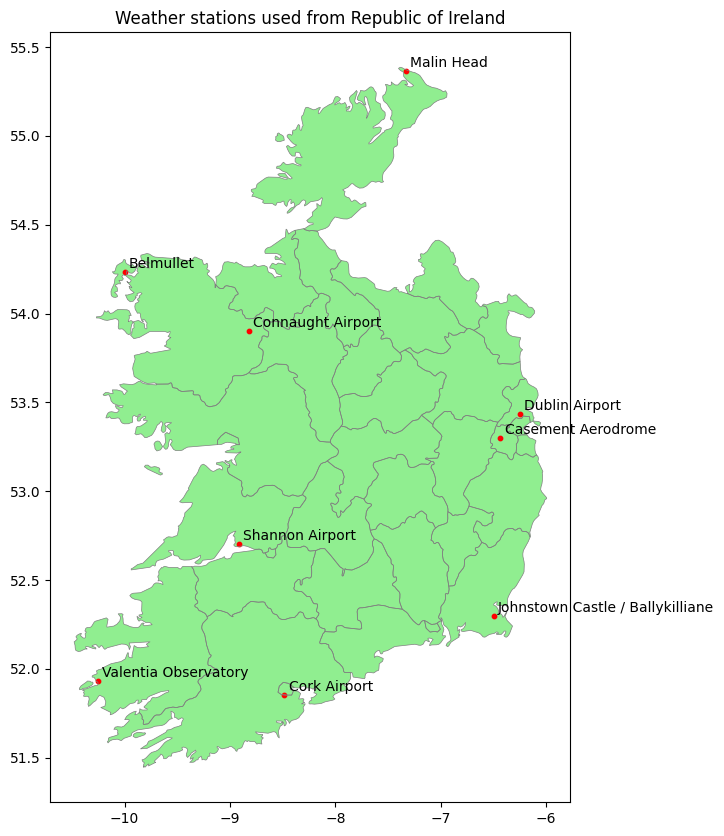

In [21]:
stations_gdf = gpd.GeoDataFrame(
    ireland_stations_all,
    geometry=gpd.points_from_xy(ireland_stations_all.longitude, ireland_stations_all.latitude),
    crs="EPSG:4326"  # WGS84 coordinate reference system (lat/lon)
)

world = gpd.read_file(f'https://raw.githubusercontent.com/SiddhanthNB/xai-gas-prediction-ireland/main/data/maps/ne_10m_admin_0_countries.geojson')
ireland = world[world['ISO_A3'] == 'IRL']

admin1 = gpd.read_file('https://raw.githubusercontent.com/SiddhanthNB/xai-gas-prediction-ireland/main/data/maps/ne_10m_admin_1_states_provinces.geojson')
ireland_counties = admin1[admin1['adm0_a3'] == 'IRL']

fig, ax = plt.subplots(figsize=(10, 10))
ireland.plot(ax=ax, color='lightgreen', edgecolor='none')
ireland_counties.boundary.plot(ax=ax, color='grey', linewidth=0.5)
stations_gdf.plot(ax=ax, color='red', markersize=10)
ax.set_title('Weather stations used from Republic of Ireland')

for x, y, label in zip(stations_gdf.geometry.x, stations_gdf.geometry.y, stations_gdf['name']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")

In [22]:
# merge climate_df with merged_data

merged_data = pd.merge(merged_data, climate_df, on='date_time', how='left')
merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff,avg_windspeed_kmph,avg_temperature_c,season
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0,20.4500,4.200000,spring
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0,25.6125,5.500000,spring
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0,20.7750,7.122222,spring
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0,25.3125,5.311111,spring
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0,24.1375,5.333333,spring


In [23]:
def fetch_irish_holidays(url):
    response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
    soup = BeautifulSoup(response.content, 'html.parser')
    rows = soup.find_all('tr', attrs={'data-date': True})

    data = []
    for row in rows:
        try:
            timestamp = int(row['data-date']) // 1000
            date = datetime.utcfromtimestamp(timestamp).date()
            cols = row.find_all('td')
            if len(cols) >= 2:
                name = cols[1].text.strip()
                holiday_type = cols[2].text.strip() if len(cols) > 2 else np.nan
                holiday_status = 'Yes' if holiday_type == 'National Holiday' else 'No'
                data.append({'date_time': date, 'name': name, 'type': holiday_type, 'holiday_status': holiday_status})
        except Exception as e:
            print(f"Error parsing row: {e}")
            continue

    return pd.DataFrame(data)

holidays_df = pd.DataFrame(columns=['date_time', 'name', 'type', 'holiday_status'])

for year in range(start_date.year, end_date.year + 1):
    url = f"https://www.timeanddate.com/holidays/ireland/{year}"
    df_year = fetch_irish_holidays(url)
    df_year['date_time'] = pd.to_datetime(df_year['date_time'])
    df_year['date'] = df_year['date_time'].dt.date
    holidays_df = pd.concat([holidays_df, df_year], ignore_index=True)

holidays_df = holidays_df.sort_values(by='date_time')
holidays_df.head()

,date_time,name,type,holiday_status,date
0,2018-01-01,New Year's Day,National Holiday,Yes,2018-01-01
1,2018-01-06,Epiphany,Observance,No,2018-01-06
2,2018-03-11,Mother's Day,Observance,No,2018-03-11
3,2018-03-17,St. Patrick's Day,National Holiday,Yes,2018-03-17
4,2018-03-20,March Equinox,Season,No,2018-03-20


In [24]:
holidays_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date_time       188 non-null    datetime64[ns]
 1   name            188 non-null    object        
 2   type            188 non-null    object        
 3   holiday_status  188 non-null    object        
 4   date            188 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 7.5+ KB


In [25]:
holidays_hash = {}
for index, row in holidays_df.iterrows():
    holidays_hash[str(row['date'])] = row['holiday_status']

merged_data['holiday_status'] = merged_data['date'].apply(lambda x: holidays_hash.get(x, 'No'))
merged_data['holiday_status'] = merged_data['holiday_status'].apply(lambda x: 1 if x == 'Yes' else 0)

In [26]:
merged_data['day_of_week'] = merged_data['date_time'].dt.day_name().str.lower()
merged_data['is_weekend'] = merged_data['day_of_week'].isin(['saturday', 'sunday']).astype(int)

In [27]:
merged_data.head()

,date_time,date,imported_supply,local_supply,total_supply,non_metered_demand,small_metered_demand,large_metered_demand,power_plant_demand,total_demand,supply_demand_diff,avg_windspeed_kmph,avg_temperature_c,season,holiday_status,day_of_week,is_weekend
0,2018-04-01,2018-04-01,39.291462,107.420343,146.711805,50.396686,8.175452,17.881889,70.257778,146.711805,0.0,20.4500,4.200000,spring,0,sunday,1
1,2018-04-02,2018-04-02,60.055502,105.556008,165.611510,54.829490,8.847883,16.848860,85.085277,165.611510,0.0,25.6125,5.500000,spring,1,monday,0
2,2018-04-03,2018-04-03,60.435102,107.306423,167.741525,44.896469,9.937754,17.283692,95.623610,167.741525,0.0,20.7750,7.122222,spring,0,tuesday,0
3,2018-04-04,2018-04-04,66.254217,107.309894,173.564111,55.070364,11.071997,17.966194,89.455556,173.564111,0.0,25.3125,5.311111,spring,0,wednesday,0
4,2018-04-05,2018-04-05,36.725712,107.334087,144.059799,54.660007,10.560184,18.097663,60.741945,144.059799,0.0,24.1375,5.333333,spring,0,thursday,0


In time-series forecasting, preserving the natural temporal structure of the data is paramount. Artificial imputation of lagged values, such as zero-filling, risks introducing bias, disrupting temporal dependencies, and ultimately degrading model learning dynamics across all model families.

In [28]:
final_df = merged_data[['date_time', 'avg_windspeed_kmph', 'avg_temperature_c', 'season', 'holiday_status', 'is_weekend', 'supply_demand_diff', 'total_demand']].copy()
final_df.head()

,date_time,avg_windspeed_kmph,avg_temperature_c,season,holiday_status,is_weekend,supply_demand_diff,total_demand
0,2018-04-01,20.4500,4.200000,spring,0,1,0.0,146.711805
1,2018-04-02,25.6125,5.500000,spring,1,0,0.0,165.611510
2,2018-04-03,20.7750,7.122222,spring,0,0,0.0,167.741525
3,2018-04-04,25.3125,5.311111,spring,0,0,0.0,173.564111
4,2018-04-05,24.1375,5.333333,spring,0,0,0.0,144.059799


In [29]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date_time           2526 non-null   datetime64[ns]
 1   avg_windspeed_kmph  2526 non-null   float64       
 2   avg_temperature_c   2526 non-null   float64       
 3   season              2526 non-null   object        
 4   holiday_status      2526 non-null   int64         
 5   is_weekend          2526 non-null   int64         
 6   supply_demand_diff  2526 non-null   float64       
 7   total_demand        2526 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 158.0+ KB


In [30]:
def one_hot_encode(df, column):
    encoder = OneHotEncoder(sparse_output=False, drop=None)
    encoded_data = encoder.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out([column]))
    df = pd.concat([df, encoded_df], axis=1)
    df = df.drop(column, axis=1)
    return df

final_df = one_hot_encode(final_df, 'season')

final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2526 entries, 0 to 2525
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date_time           2526 non-null   datetime64[ns]
 1   avg_windspeed_kmph  2526 non-null   float64       
 2   avg_temperature_c   2526 non-null   float64       
 3   holiday_status      2526 non-null   int64         
 4   is_weekend          2526 non-null   int64         
 5   supply_demand_diff  2526 non-null   float64       
 6   total_demand        2526 non-null   float64       
 7   season_autumn       2526 non-null   float64       
 8   season_spring       2526 non-null   float64       
 9   season_summer       2526 non-null   float64       
 10  season_winter       2526 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usage: 217.2 KB


<a id="section_4"></a>
## 4. Exploratory Data Analysis (EDA)

We explore the dataset to understand the underlying patterns and relationships between variables. Visualizations are used to identify trends and anomalies.

In [31]:
import seaborn as sns

In [59]:
eda_df = final_df.copy()

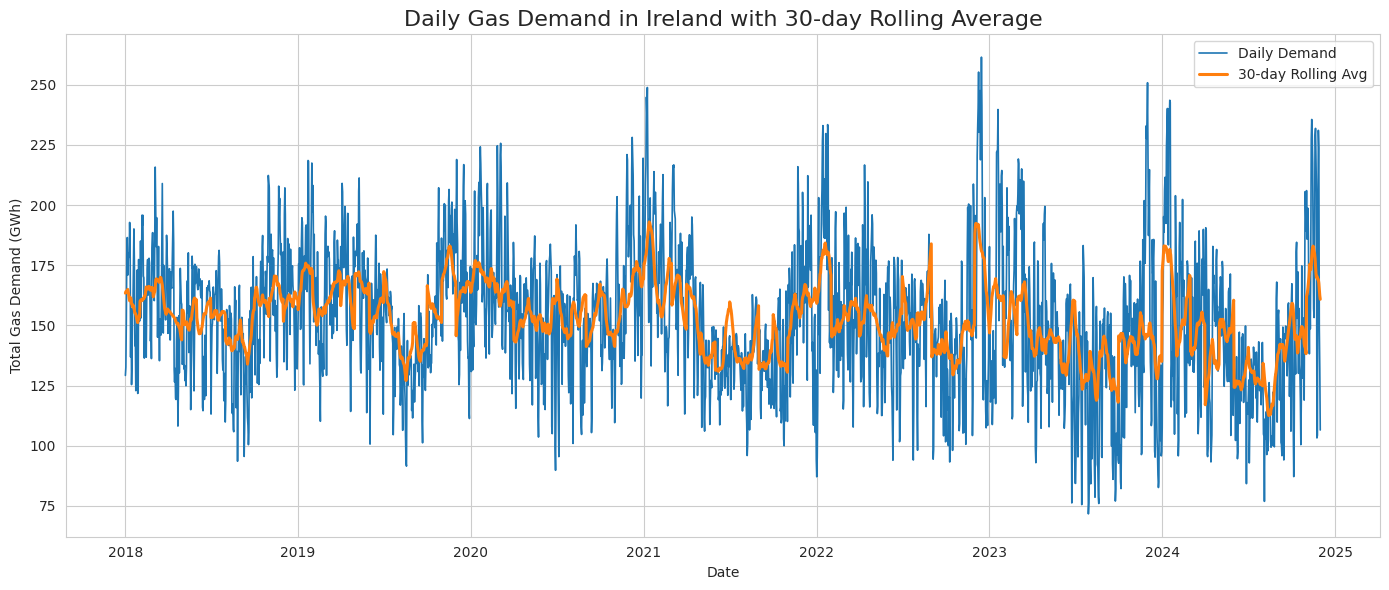

In [60]:
eda_df['rolling_demand'] = eda_df['total_demand'].rolling(window=30, center=True).mean()

plt.figure(figsize=(14, 6))
sns.set_style('whitegrid')

sns.lineplot(data=eda_df, x='date_time', y='total_demand', label='Daily Demand', linewidth=1.2)
sns.lineplot(data=eda_df, x='date_time', y='rolling_demand', label='30-day Rolling Avg', linewidth=2.2)

plt.title('Daily Gas Demand in Ireland with 30-day Rolling Average', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Gas Demand (GWh)')
plt.legend()
plt.tight_layout()
plt.show()

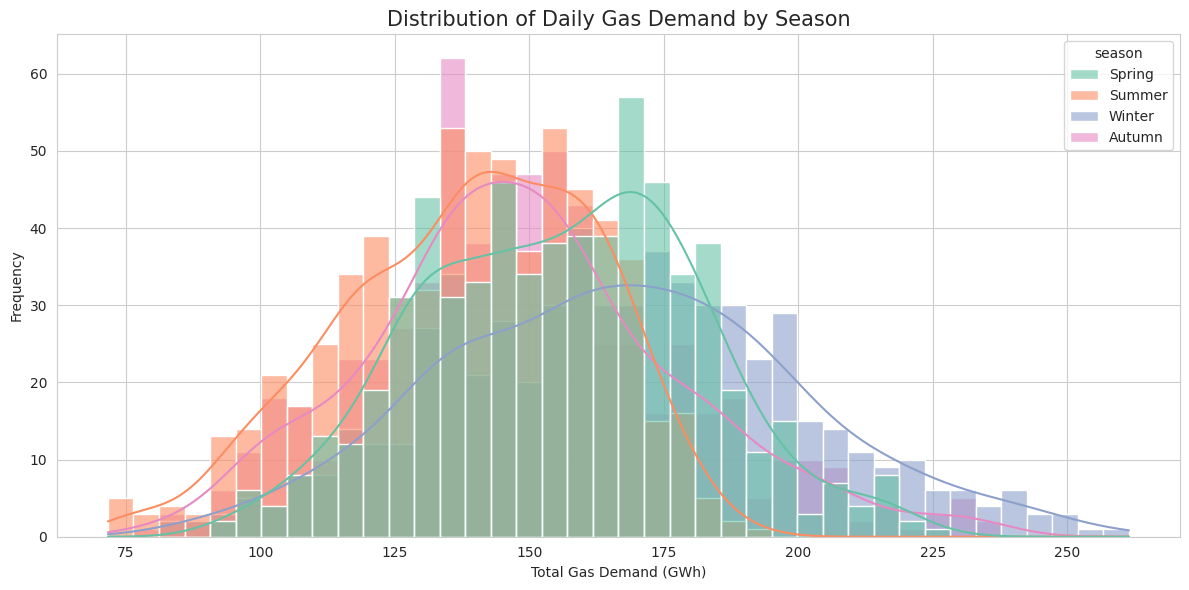

In [61]:
season_cols = ['season_autumn', 'season_winter', 'season_summer', 'season_spring']
eda_df['season'] = eda_df[season_cols].idxmax(axis=1).str.replace('season_', '').str.capitalize()

plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

sns.histplot(
    data=eda_df,
    x='total_demand',
    hue='season',
    kde=True,
    palette='Set2',
    bins=40,
    alpha=0.6,
    legend=True
)

plt.title('Distribution of Daily Gas Demand by Season', fontsize=15)
plt.xlabel('Total Gas Demand (GWh)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

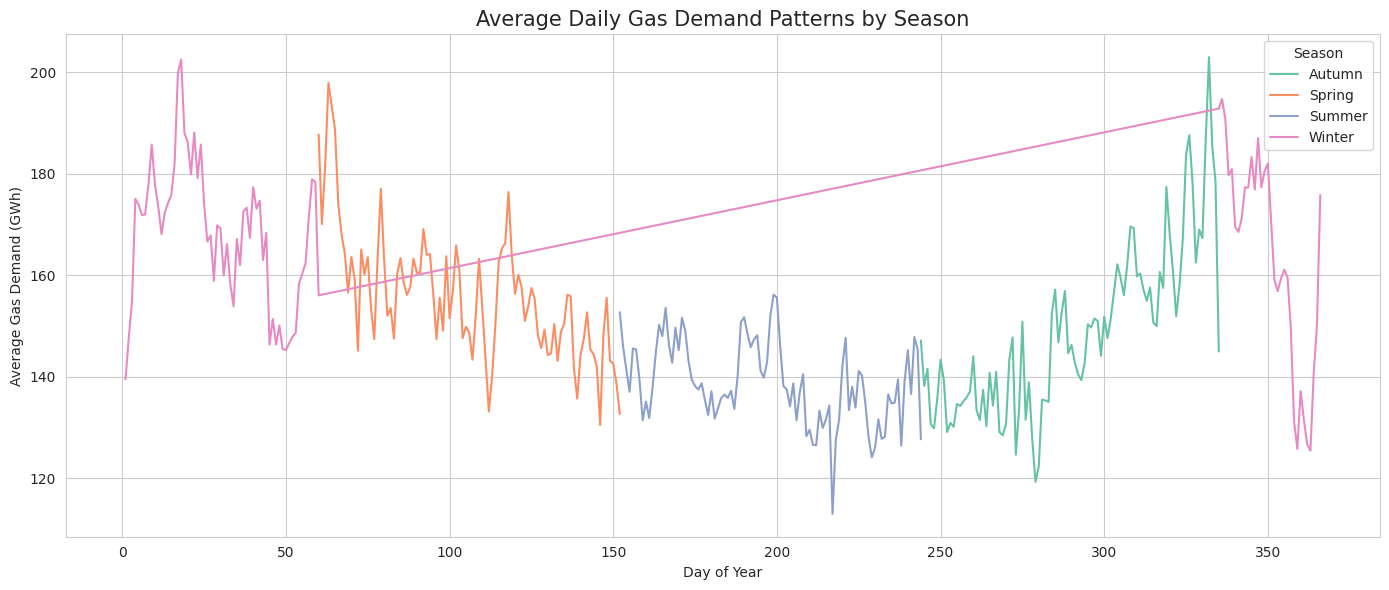

In [62]:
eda_df['day_of_year'] = eda_df['date_time'].dt.dayofyear

seasonal_avg = eda_df.groupby(['season', 'day_of_year'])['total_demand'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.set_style('whitegrid')

sns.lineplot(data=seasonal_avg, x='day_of_year', y='total_demand', hue='season', palette='Set2')

plt.title('Average Daily Gas Demand Patterns by Season', fontsize=15)
plt.xlabel('Day of Year')
plt.ylabel('Average Gas Demand (GWh)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

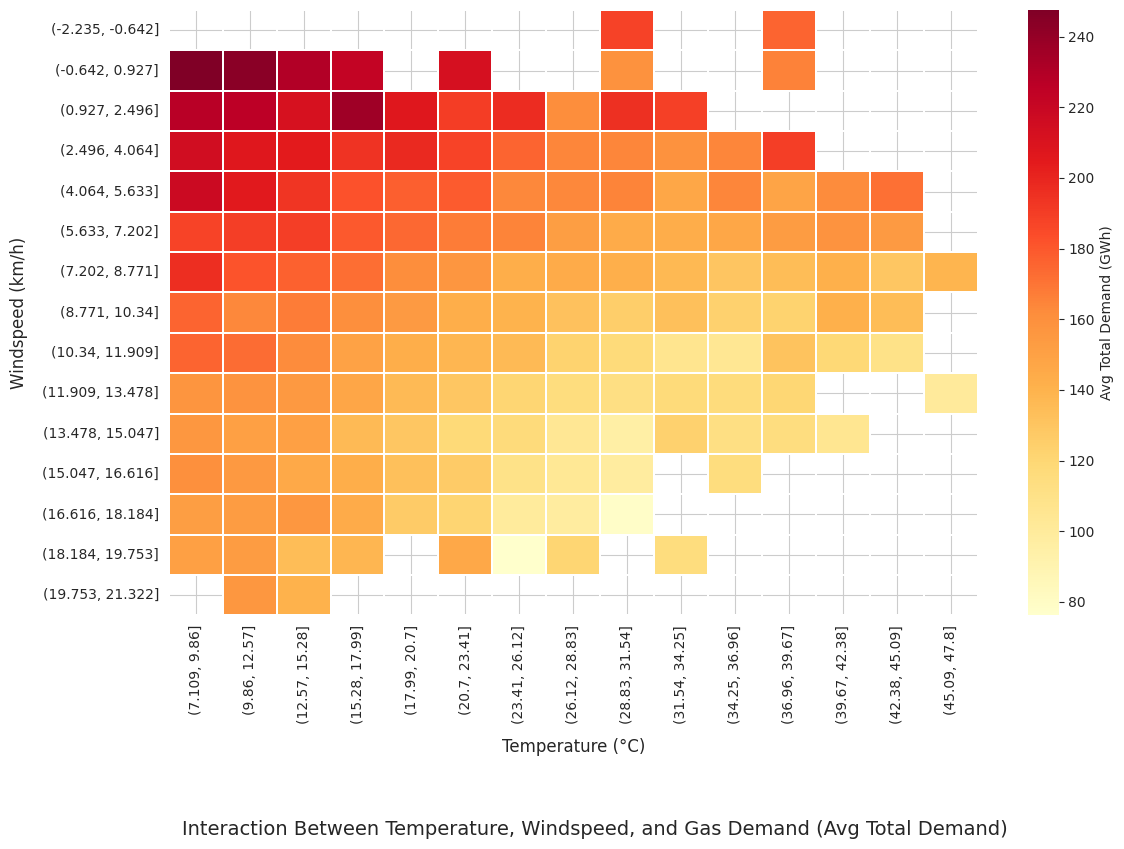

In [63]:
eda_df['temp_bin'] = pd.cut(eda_df['avg_temperature_c'], bins=15)
eda_df['wind_bin'] = pd.cut(eda_df['avg_windspeed_kmph'], bins=15)

pivot_table = eda_df.pivot_table(
    values='total_demand',
    index='temp_bin',
    columns='wind_bin',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.heatmap(
    pivot_table,
    cmap='YlOrRd',
    linewidths=0.05,
    cbar_kws={'label': 'Avg Total Demand (GWh)'}
)

plt.xlabel('Temperature (°C)', fontsize=12, labelpad=10)
plt.ylabel('Windspeed (km/h)', fontsize=12, labelpad=10)

plt.title('', pad=20)

plt.figtext(0.5, -0.05, 'Interaction Between Temperature, Windspeed, and Gas Demand (Avg Total Demand)', wrap=True, horizontalalignment='center', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

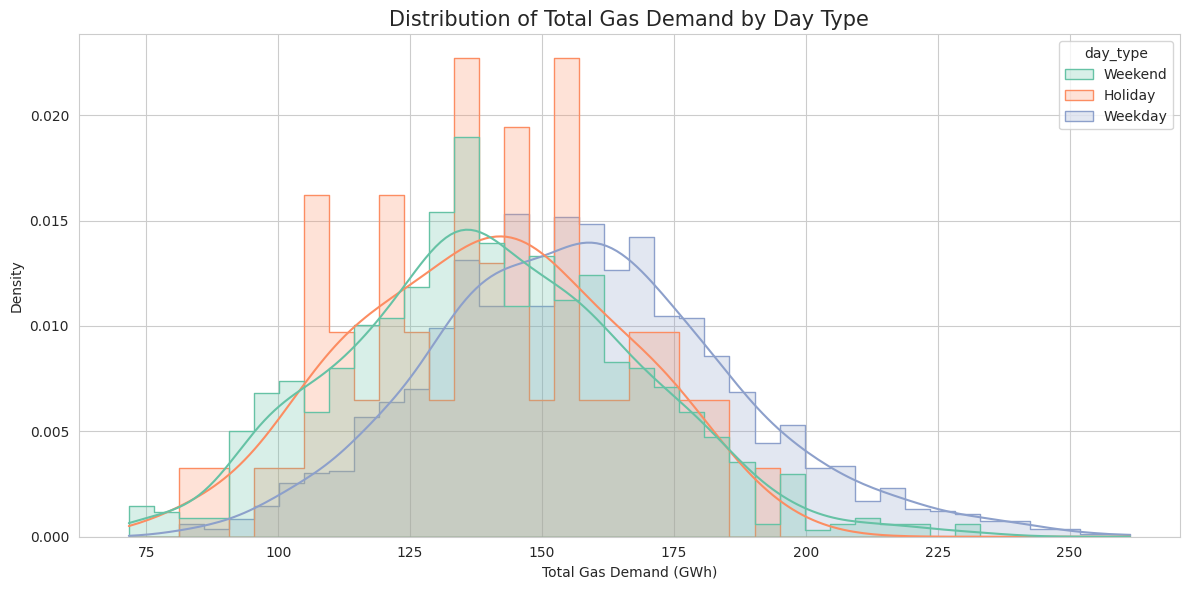

In [64]:
def classify_day(row):
    if row['holiday_status'] == 1:
        return 'Holiday'
    elif row['is_weekend'] == 1:
        return 'Weekend'
    else:
        return 'Weekday'

eda_df['day_type'] = eda_df.apply(classify_day, axis=1)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(
    data=eda_df,
    x='total_demand',
    hue='day_type',
    bins=40,
    kde=True,
    stat='density',
    palette='Set2',
    element='step',
    common_norm=False,
    legend=True
)

plt.title('Distribution of Total Gas Demand by Day Type', fontsize=15)
plt.xlabel('Total Gas Demand (GWh)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

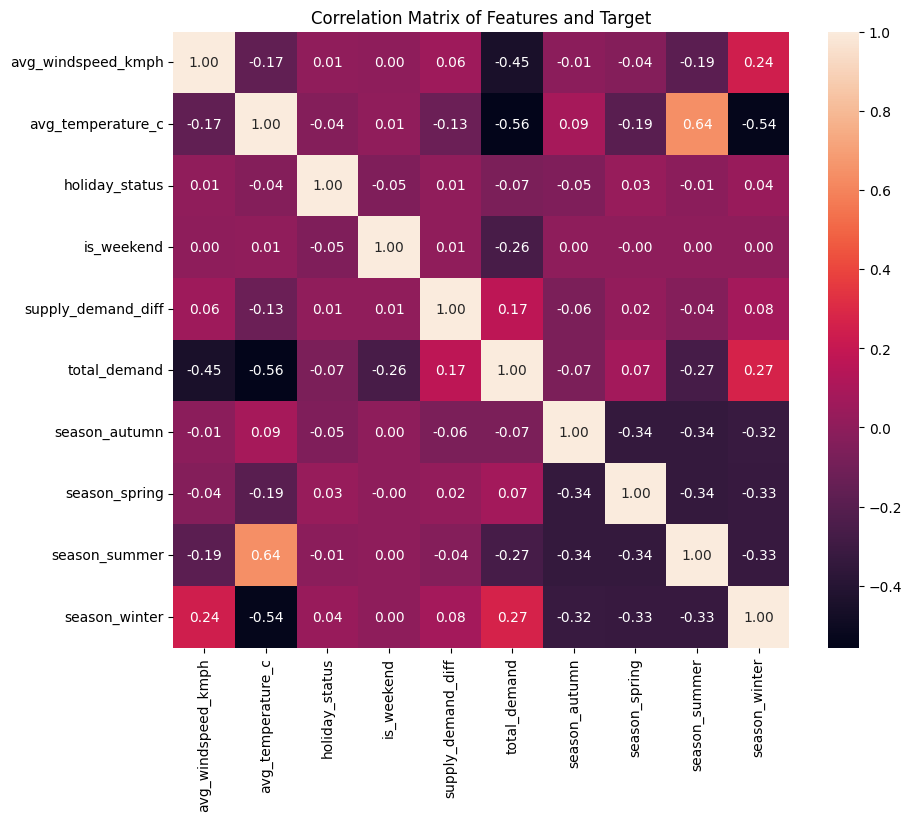

In [32]:
corr_matrix = eda_df.drop(columns=['date_time']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", square=True)
plt.title('Correlation Matrix of Features and Target')
plt.show()

<a id="section_5"></a>
## 5. Model Building

We develop machine learning models to predict daily gas demand. The models are trained and evaluated using appropriate metrics.

In [33]:
import xgboost as xgb
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [34]:
model_performances = {}

In [35]:
list(final_df.columns)

['date_time',
 'avg_windspeed_kmph',
 'avg_temperature_c',
 'holiday_status',
 'is_weekend',
 'supply_demand_diff',
 'total_demand',
 'season_autumn',
 'season_spring',
 'season_summer',
 'season_winter']

<a id="subsection_5_1"></a>
### 5.1 Linear Regression

In [36]:
relevant_columns = [
    'avg_windspeed_kmph', 'avg_temperature_c', 'holiday_status', 'is_weekend',
    'season_spring', 'season_summer', 'season_autumn', 'season_winter'
]

X = final_df[relevant_columns]
y = final_df['total_demand']

non_numerical_cols = ['holiday_status', 'is_weekend', 'season_spring', 'season_summer', 'season_autumn', 'season_winter']
numerical_cols = list(set(relevant_columns) - set(non_numerical_cols))

train_size = int(len(y) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

model_name = 'Linear Regression'

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_performances[model_name] = { 'mse': mse, 'mae': mae, 'r2': r2 }

print(f"{model_name} Test MSE: {mse:.2f}")
print(f"{model_name} Test MAE: {mae:.2f}")
print(f"{model_name} Test R2 Score: {r2:.4f}")

Linear Regression Test MSE: 361.70
Linear Regression Test MAE: 15.90
Linear Regression Test R2 Score: 0.6735


<a id="subsection_5_2"></a>
### 5.2 SARIMAX

In [37]:
sarimax_df = final_df.copy()

sarimax_df['date_time'] = pd.to_datetime(sarimax_df['date_time'])
sarimax_df = sarimax_df.set_index('date_time')

target = 'total_demand'
relevant_columns = [
    'avg_windspeed_kmph', 'avg_temperature_c', 'holiday_status', 'is_weekend',
    'season_spring', 'season_summer', 'season_autumn', 'season_winter'
]

y = sarimax_df[target]
X = sarimax_df[relevant_columns]

train_size = int(len(y) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

sarimax_model = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=(0, 0, 0),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=True,
    enforce_invertibility=True
)

sarimax_result = sarimax_model.fit(disp=False)
y_pred = sarimax_result.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1, exog=X_test)

model_name = 'SARIMAX'

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_performances[model_name] = { 'mse': mse, 'mae': mae, 'r2': r2 }

print(f"{model_name} Test MSE: {mse:.2f}")
print(f"{model_name} Test MAE: {mae:.2f}")
print(f"{model_name} Test R2 Score: {r2:.4f}")

SARIMAX Test MSE: 296.30
SARIMAX Test MAE: 14.13
SARIMAX Test R2 Score: 0.7326


<a id="subsection_5_3"></a>
### 5.3 Time-Based and Seasonal Interaction Features for Ensemble Models

In [38]:
# --- Generate cyclical features to capture annual seasonality ---
final_df['day_of_year'] = final_df['date_time'].dt.dayofyear
final_df['day_of_year_sin'] = np.sin(2 * np.pi * final_df['day_of_year'] / 365.25)
final_df['day_of_year_cos'] = np.cos(2 * np.pi * final_df['day_of_year'] / 365.25)
final_df = final_df.drop('day_of_year', axis=1)

# --- LAG FEATURES (t-1, t-7) ---
for col in ['total_demand', 'supply_demand_diff', 'avg_temperature_c', 'avg_windspeed_kmph']:
    for lag in [1, 7]:
        final_df[f'{col}_t-{lag}'] = final_df[col].shift(lag)

# --- 7-DAY Exponentially Weighted Moving Average FEATURES ---
for col in ['total_demand', 'supply_demand_diff', 'avg_temperature_c', 'avg_windspeed_kmph']:
    final_df[f'{col}_rolling_7'] = final_df[col].ewm(span=7, adjust=False).mean()

# --- SEASONAL INTERACTIONS WITH TEMPERATURE AND WINDSPEED ---
for season in ['season_spring', 'season_summer', 'season_autumn', 'season_winter']:
    final_df[f'temp_x_{season}'] = final_df['avg_temperature_c'] * final_df[season]
    final_df[f'windspeed_x_{season}'] = final_df['avg_windspeed_kmph'] * final_df[season]

# drop null vlaues
final_df.dropna(inplace=True)

final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2519 entries, 7 to 2525
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date_time                     2519 non-null   datetime64[ns]
 1   avg_windspeed_kmph            2519 non-null   float64       
 2   avg_temperature_c             2519 non-null   float64       
 3   holiday_status                2519 non-null   int64         
 4   is_weekend                    2519 non-null   int64         
 5   supply_demand_diff            2519 non-null   float64       
 6   total_demand                  2519 non-null   float64       
 7   season_autumn                 2519 non-null   float64       
 8   season_spring                 2519 non-null   float64       
 9   season_summer                 2519 non-null   float64       
 10  season_winter                 2519 non-null   float64       
 11  day_of_year_sin               2519 

In [39]:
relevant_columns = [
    'avg_windspeed_kmph', 'avg_temperature_c', 'holiday_status', 'is_weekend',
    'day_of_year_sin', 'day_of_year_cos', 'total_demand_t-1',
    'total_demand_t-7', 'supply_demand_diff_t-1', 'supply_demand_diff_t-7',
    'avg_temperature_c_t-1', 'avg_temperature_c_t-7',
    'avg_windspeed_kmph_t-1', 'avg_windspeed_kmph_t-7',
    'total_demand_rolling_7', 'supply_demand_diff_rolling_7',
    'avg_temperature_c_rolling_7', 'avg_windspeed_kmph_rolling_7',
    'temp_x_season_spring', 'windspeed_x_season_spring',
    'temp_x_season_summer', 'windspeed_x_season_summer',
    'temp_x_season_autumn', 'windspeed_x_season_autumn',
    'temp_x_season_winter', 'windspeed_x_season_winter'
]

In [40]:
X = final_df[relevant_columns]
y = final_df['total_demand']

non_numerical_cols = ['holiday_status', 'is_weekend', 'season_spring', 'season_summer', 'season_autumn', 'season_winter']
numerical_cols = list(set(relevant_columns) - set(non_numerical_cols))

train_size = int(len(final_df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [41]:
# for future refernce

X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test, columns=X_test.columns)

display(X_train_df)
display(X_test_df)

,avg_windspeed_kmph,avg_temperature_c,holiday_status,is_weekend,day_of_year_sin,day_of_year_cos,total_demand_t-1,total_demand_t-7,supply_demand_diff_t-1,supply_demand_diff_t-7,...,avg_temperature_c_rolling_7,avg_windspeed_kmph_rolling_7,temp_x_season_spring,windspeed_x_season_spring,temp_x_season_summer,windspeed_x_season_summer,temp_x_season_autumn,windspeed_x_season_autumn,temp_x_season_winter,windspeed_x_season_winter
7,-1.384262,-0.428313,0,1,1.416205,-0.164764,0.634376,-0.271662,0.579989,0.575834,...,-0.879715,-0.217606,1.584569,0.582331,-0.595641,-0.561190,-0.515517,-0.507167,-0.552983,-0.56054
8,-0.761806,-0.518780,0,0,1.413152,-0.188509,0.412520,0.396419,0.579989,0.575834,...,-0.809088,-0.466364,1.494747,1.084201,-0.595641,-0.561190,-0.515517,-0.507167,-0.552983,-0.56054
9,0.117260,-0.554419,0,0,1.409678,-0.212200,0.391137,0.471713,0.579989,0.575834,...,-0.766449,-0.303982,1.459362,1.792969,-0.595641,-0.561190,-0.515517,-0.507167,-0.552983,-0.56054
10,-0.753137,-0.568126,0,0,1.405782,-0.235830,0.741741,0.677534,0.579989,0.575834,...,-0.738444,-0.527705,1.445753,1.091191,-0.595641,-0.561190,-0.515517,-0.507167,-0.552983,-0.56054
11,-0.605759,-0.557160,0,0,1.401467,-0.259391,1.072008,-0.365407,0.579989,0.575834,...,-0.714261,-0.636994,1.456640,1.210018,-0.595641,-0.561190,-0.515517,-0.507167,-0.552983,-0.56054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017,-0.857169,1.518111,0,1,0.509895,-1.300935,-1.544124,-0.688297,-2.502555,-2.139984,...,1.439652,-0.857794,-0.527615,-0.516469,1.887008,1.119361,-0.515517,-0.507167,-0.552983,-0.56054
2018,-1.332246,1.773065,0,1,0.486761,-1.309440,-1.319393,-1.093514,-1.722680,-1.789159,...,1.594846,-1.172944,-0.527615,-0.516469,2.042382,0.696910,-0.515517,-0.507167,-0.552983,-0.56054
2019,-1.373859,1.603096,0,0,0.463479,-1.317560,-0.591112,-0.696399,-1.271183,-2.164739,...,1.661967,-1.425825,-0.527615,-0.516469,1.938799,0.659907,-0.515517,-0.507167,-0.552983,-0.56054
2020,-1.287166,1.973191,0,0,0.440056,-1.325291,0.164291,-0.372701,-2.354790,-1.937745,...,1.819599,-1.581073,-0.527615,-0.516469,2.164343,0.736997,-0.515517,-0.507167,-0.552983,-0.56054


,avg_windspeed_kmph,avg_temperature_c,holiday_status,is_weekend,day_of_year_sin,day_of_year_cos,total_demand_t-1,total_demand_t-7,supply_demand_diff_t-1,supply_demand_diff_t-7,...,avg_temperature_c_rolling_7,avg_windspeed_kmph_rolling_7,temp_x_season_spring,windspeed_x_season_spring,temp_x_season_summer,windspeed_x_season_summer,temp_x_season_autumn,windspeed_x_season_autumn,temp_x_season_winter,windspeed_x_season_winter
2022,-1.342649,1.704529,0,0,0.392815,-1.339578,-0.229371,-1.665807,-1.895078,-2.684788,...,1.941453,-1.724784,-0.527615,-0.516469,2.000615,0.687660,-0.515517,-0.507167,-0.552983,-0.56054
2023,-0.756605,1.597613,0,0,0.369011,-1.346131,0.303542,-1.549103,-1.468199,-2.523826,...,1.920333,-1.594683,-0.527615,-0.516469,1.935458,1.208784,-0.515517,-0.507167,-0.552983,-0.56054
2024,-0.933459,1.509887,0,1,0.345093,-1.352287,0.045891,-1.324029,-2.654428,-1.739621,...,1.879061,-1.567310,-0.527615,-0.516469,1.881996,1.051522,-0.515517,-0.507167,-0.552983,-0.56054
2025,-0.831161,1.529077,0,1,0.321070,-1.358044,-0.610321,-0.594634,-2.190608,-1.285617,...,1.853670,-1.506173,-0.527615,-0.516469,1.893690,1.142487,-0.515517,-0.507167,-0.552983,-0.56054
2026,-0.950797,1.551008,0,0,0.296948,-1.363400,-1.018218,0.161925,-2.358898,-2.375240,...,1.840985,-1.507810,-0.527615,-0.516469,1.907056,1.036104,-0.515517,-0.507167,-0.552983,-0.56054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2521,1.249471,-0.047252,0,0,-1.448576,-0.099242,-0.283704,-0.338958,-0.524142,-0.117571,...,0.424250,-0.326288,-0.527615,-0.516469,-0.595641,-0.561190,1.605162,2.739571,-0.552983,-0.56054
2522,0.694636,-0.184324,0,0,-1.450039,-0.075356,-1.192438,-0.246100,-0.277876,-0.654128,...,0.265845,0.030268,-0.527615,-0.516469,-0.595641,-0.561190,1.489278,2.288831,-0.552983,-0.56054
2523,-0.891846,-0.121271,0,1,-1.451076,-0.051449,-0.711562,-0.895793,-1.328649,-0.555066,...,0.165320,-0.332079,-0.527615,-0.516469,-0.595641,-0.561190,1.542584,0.999995,-0.552983,-0.56054
2524,0.814272,0.292687,0,1,-1.451688,-0.027528,-0.088742,-0.632146,-1.870445,-0.237257,...,0.209934,0.073415,-0.527615,-0.516469,-0.595641,-0.561190,1.892554,2.386021,-0.552983,-0.56054


<a id="subsection_5_4"></a>
### 5.4 Random Forest

In [42]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

model_name = 'Random Forest'

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_performances[model_name] = { 'mse': mse, 'mae': mae, 'r2': r2 }

print(f"{model_name} Test MSE: {mse:.2f}")
print(f"{model_name} Test MAE: {mae:.2f}")
print(f"{model_name} Test R2 Score: {r2:.4f}")

Random Forest Test MSE: 194.64
Random Forest Test MAE: 10.62
Random Forest Test R2 Score: 0.8249


<a id="subsection_5_5"></a>
### 5.5 Extreme Gradient Boosting - XGBoost

In [43]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

model_name = 'XGBoost'

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_performances[model_name] = { 'mse': mse, 'mae': mae, 'r2': r2 }

print(f"{model_name} Test MSE: {mse:.2f}")
print(f"{model_name} Test MAE: {mae:.2f}")
print(f"{model_name} Test R2 Score: {r2:.4f}")

XGBoost Test MSE: 131.45
XGBoost Test MAE: 8.97
XGBoost Test R2 Score: 0.8818


<a id="subsection_5_6"></a>
### 5.6 Grid Search with Time-Aware Cross-Validation for XGBoost

In [44]:
def get_important_features(model, feature_names):
    importances = model.feature_importances_
    feature_importance = pd.Series(importances, index=feature_names)
    feature_importance = feature_importance.sort_values(ascending=False)
    return feature_importance

In [45]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

xgb_base_model = xgb.XGBRegressor(random_state=42, n_jobs=1)

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=xgb_base_model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)
xgb_best_model = grid_search.best_estimator_
y_pred = xgb_best_model.predict(X_test)

model_name = 'XGBoost Light Tuned'

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

model_performances[model_name] = { 'mse': mse, 'mae': mae, 'r2': r2 }

print(f"{model_name} Test MSE: {mse:.2f}")
print(f"{model_name} Test MAE: {mae:.2f}")
print(f"{model_name} Test R2 Score: {r2:.4f}")

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
XGBoost Light Tuned Test MSE: 123.48
XGBoost Light Tuned Test MAE: 8.81
XGBoost Light Tuned Test R2 Score: 0.8889


In [46]:
get_important_features(xgb_best_model, X_train.columns)

,0
total_demand_rolling_7,0.307869
is_weekend,0.121858
avg_windspeed_kmph,0.101575
avg_temperature_c,0.100683
windspeed_x_season_winter,0.049227
windspeed_x_season_summer,0.048227
holiday_status,0.046511
total_demand_t-1,0.032234
day_of_year_cos,0.023772
windspeed_x_season_spring,0.016820


<a id="section_6"></a>
## 6. Model Evaluation

In [47]:
model_performances_df = pd.DataFrame.from_dict(model_performances, orient='index')
model_performances_df['rmse'] = np.sqrt(model_performances_df['mse'])
model_performances_df[['mae', 'mse', 'rmse', 'r2']]

,mae,mse,rmse,r2
Linear Regression,15.899119,361.703506,19.018504,0.673524
SARIMAX,14.125994,296.296687,17.213271,0.732561
Random Forest,10.623911,194.638891,13.951304,0.824924
XGBoost,8.973862,131.445097,11.464951,0.881766
XGBoost Light Tuned,8.809723,123.479701,11.112142,0.888931


<a id="section_7"></a>
## 7. Explainable AI (XAI)

To understand the model's decisions, we employ explainability techniques such as SHAP values and Partial Dependence Plots. These tools help interpret the influence of features on the predictions.

In [48]:
!pip --quiet install dice-ml shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 41.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 1.5.3 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
mizani 0.13.3 requires pandas>=2.2.0, but you have pandas 1.5.3 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 1.5.3 which is incompatible.
dask-expr 1.1.21 requires pandas>=2, but you have pandas 1.5.3 which is incompatible.
xarray 2025.3.1 requires pandas>=2.1, but you have pandas 1.5.3 which is incompatible.


In [49]:
import shap
import dice_ml
from sklearn.inspection import PartialDependenceDisplay

<a id="subsection_7_1"></a>
### 7.1 TreeExplainer using SHAP

In [50]:
# Create SHAP tree explainer for ensemble models
explainer = shap.TreeExplainer(xgb_best_model)
shap_values = explainer.shap_values(X_test_df)

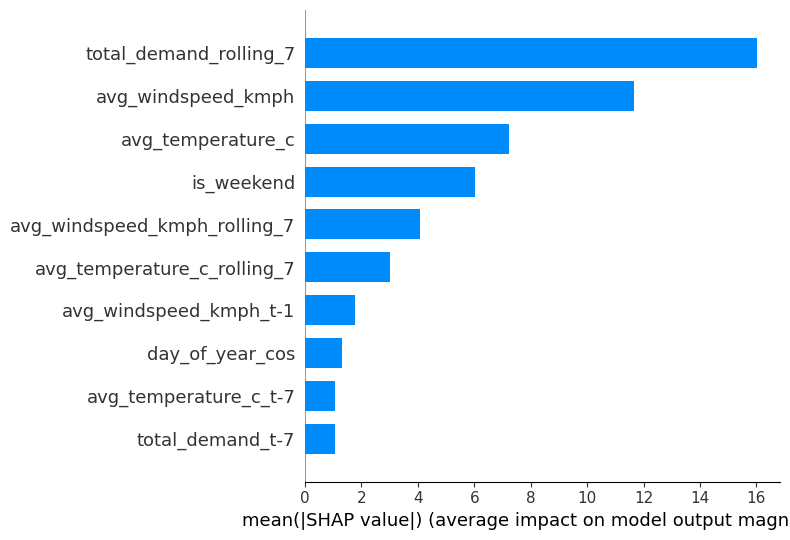

In [51]:
# Global explanation: SHAP summary bar plot
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=10)

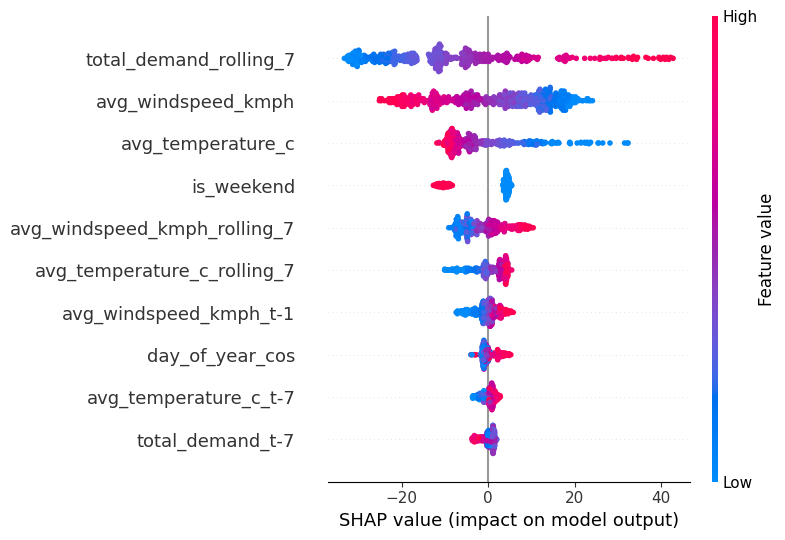

In [52]:
# Global explaination: SHAP summary dot plot

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_df, max_display=10)

SHAP Summary Plot Interpretation

The SHAP summary plot provides a global explanation of the XGBoost model’s behavior by showing how the top 10 features contribute to daily gas demand predictions across the dataset.

Key insights include:

  * Recent demand, temperature, and weekend indicators are the most influential features.

  * Low temperatures and recent high demand strongly increase predicted gas usage, while high temperatures and weekends tend to decrease it.

  * The color gradient highlights how feature values (high or low) affect the direction and strength of their impact.

Overall, the model captures both seasonal patterns and short-term behavioral factors, supporting the hypothesis that weather, time, and demand history significantly influence gas consumption. This aligns directly with RQ1 (importance of seasonality and weather) and RQ3 (transparent feature impact through SHAP).

,date_time,avg_windspeed_kmph,avg_temperature_c,holiday_status,is_weekend,supply_demand_diff,total_demand,season_autumn,season_spring,season_summer,...,avg_temperature_c_rolling_7,avg_windspeed_kmph_rolling_7,temp_x_season_spring,windspeed_x_season_spring,temp_x_season_summer,windspeed_x_season_summer,temp_x_season_autumn,windspeed_x_season_autumn,temp_x_season_winter,windspeed_x_season_winter
2525,2024-09-30,17.1375,11.522222,0,0,-0.018056,159.760386,1.0,0.0,0.0,...,11.188043,19.398146,0.0,0.0,0.0,0.0,11.522222,17.1375,0.0,0.0



Prediction: 160.29917907714844


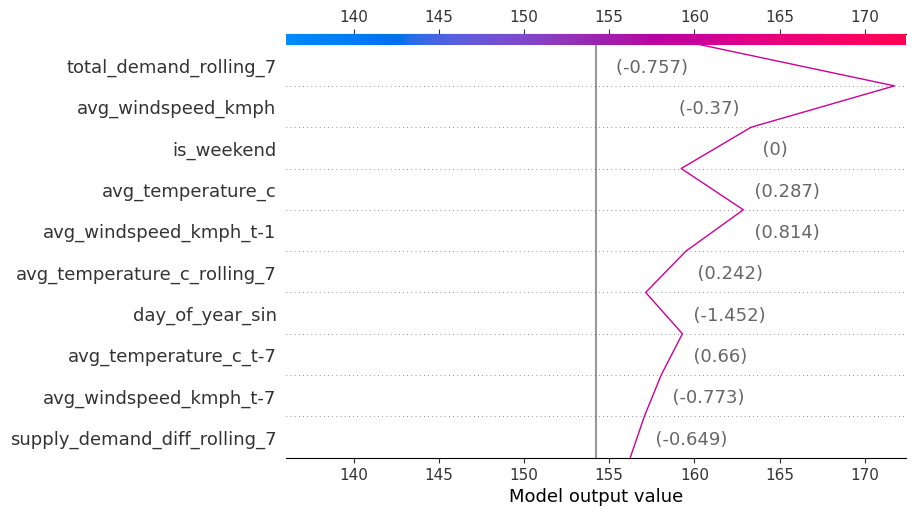

In [53]:
# Local explaination

instance_idx = -1 #for last date_time

display(final_df.iloc[[instance_idx]])

print(f"\nPrediction: {xgb_best_model.predict(X_test_df.iloc[[instance_idx]])[0]}")

plt.figure(figsize=(8, 6))
shap.decision_plot(explainer.expected_value, shap_values[instance_idx], X_test_df.iloc[instance_idx], feature_display_range=slice(-1, -11, -1))

Local Explanation Summary (2024-09-30)

The model's base prediction (expected value) for this instance starts at ~153.5. Each feature then pushes the prediction up or down, resulting in a final forecast of ~167 MWh.

On this day:

  * The past week's temperature (12.88°C) and yesterday's windspeed (13.52 km/h) pushed the prediction upward.

  * Being a weekend and the time of year (late September) slightly reduced the prediction.

  * Other features like past demand and 7-day averages contributed smaller adjustments.

The final prediction reflects how weather, seasonality, and day type combine to influence gas demand. This illustrates clear, human-understandable reasoning behind the model’s output.

<a id="subsection_7_2"></a>
### 7.2 SHAP Interaction Plots

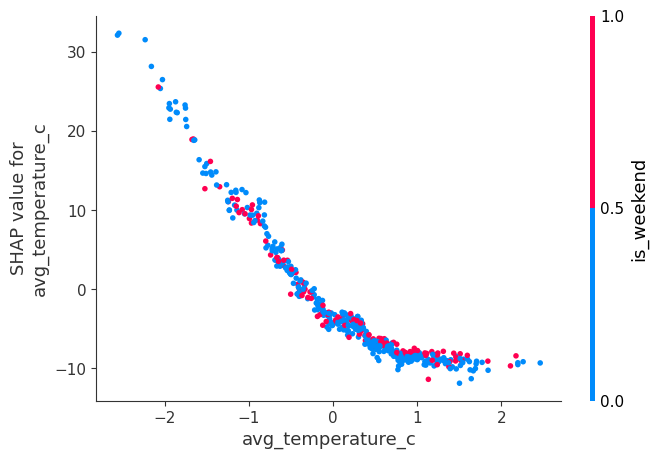

In [54]:
# whether temperature affects demand differently on weekends vs. weekdays

shap.dependence_plot("avg_temperature_c", shap_values, X_test_df, interaction_index="is_weekend")

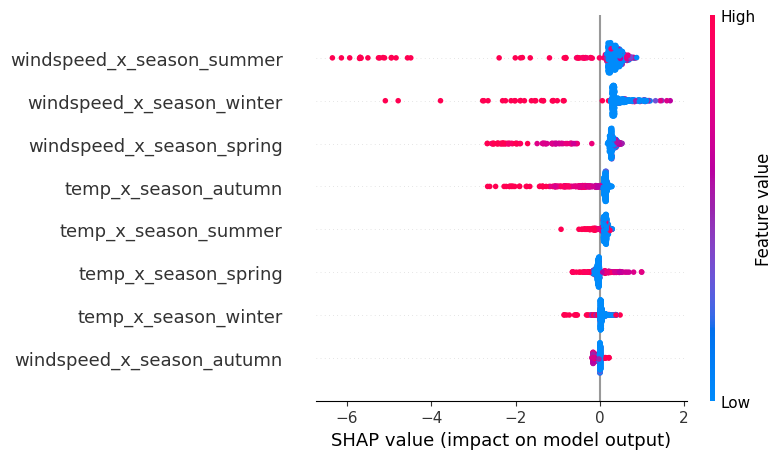

In [55]:
interaction_cols = [
    'temp_x_season_spring', 'temp_x_season_summer',
    'temp_x_season_autumn', 'temp_x_season_winter',
    'windspeed_x_season_spring', 'windspeed_x_season_summer',
    'windspeed_x_season_autumn', 'windspeed_x_season_winter'
]

shap.summary_plot(shap_values[:, [X_test_df.columns.get_loc(col) for col in interaction_cols]], X_test_df[interaction_cols])

This SHAP analysis of engineered season-weather interaction features reveals that windspeed in summer is the most influential interaction, significantly reducing predicted gas demand. Other wind-related interactions (especially in winter and spring) also contribute slightly. In contrast, the model places little weight on the temperature-season interactions — likely because base temperature features already explain most of the variation. These insights highlight the model's ability to capture seasonal behavioral patterns, especially around summer wind conditions.

<a id="subsection_7_3"></a>
### 7.3 Partial Dependence Plots - PDP

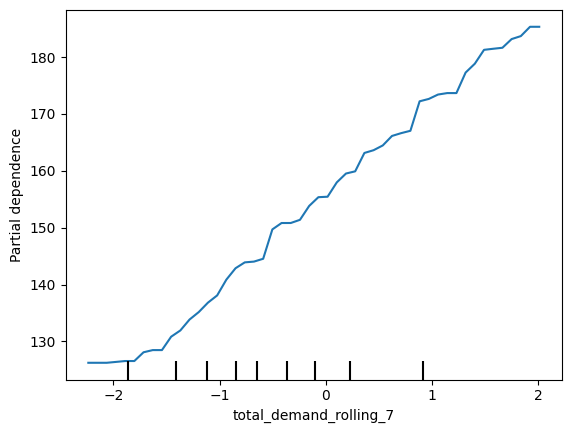

In [56]:
PartialDependenceDisplay.from_estimator(
    xgb_best_model,
    X_test,
    ['total_demand_rolling_7'],
    kind='average',
    grid_resolution=50,
    feature_names=X_test.columns,
)

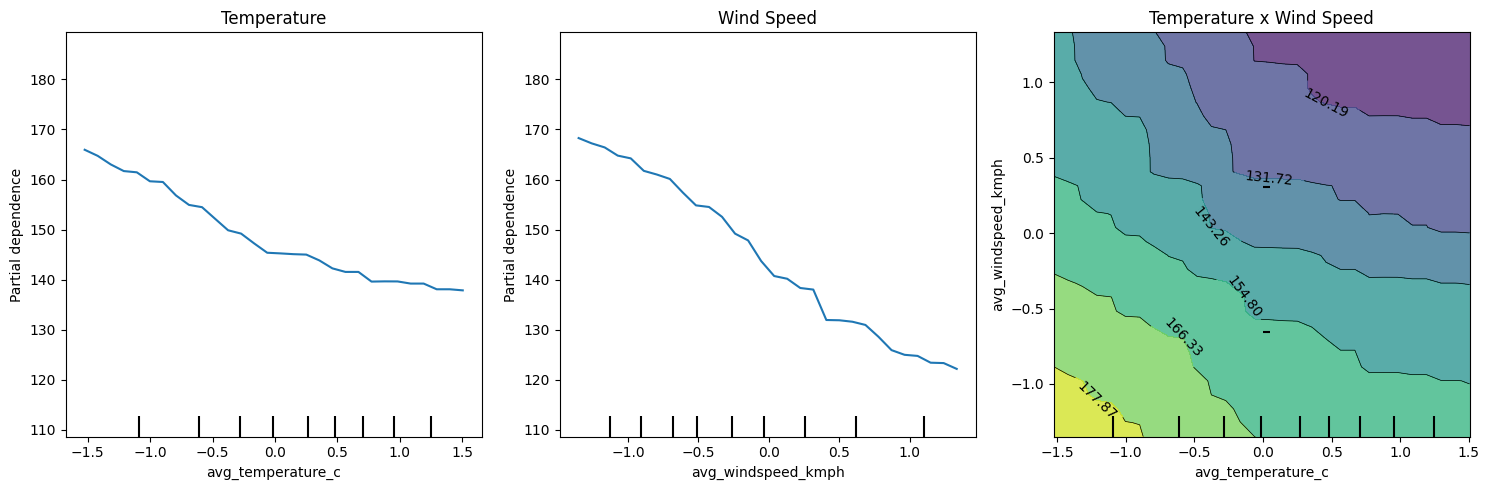

In [57]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

disp = PartialDependenceDisplay.from_estimator(
    xgb_best_model,
    X_test,
    ['avg_temperature_c', 'avg_windspeed_kmph', ('avg_temperature_c', 'avg_windspeed_kmph')],
    kind='average',
    grid_resolution=30,
    feature_names=X_test.columns,
    ax=ax
)

ax[0].set_title('Temperature')
ax[1].set_title('Wind Speed')
ax[2].set_title('Temperature x Wind Speed')

plt.tight_layout()
plt.show()

The PDP analysis shows that:
* Gas demand decreases steadily with warmer conditions before hitting saturation after certain temperature.
* Gas demand has a very sharp and inverse relationship with windspeed.
* The 2D partial dependence plot shows that predicted gas demand is highest on cold, calm days and lowest on warm, windy days. Both temperature and windspeed influence demand jointly and consistently, confirming their combined impact on heating-related gas usage.

<a id="subsection_7_4"></a>
### 7.4 Diverse Counterfactual Explanations - DiCE

In [58]:
d = dice_ml.Data(
    dataframe=final_df[relevant_columns + ['total_demand']],
    continuous_features=relevant_columns,
    outcome_name='total_demand'
)

m = dice_ml.Model(model=xgb_best_model, backend="sklearn", model_type='regressor')

exp = dice_ml.Dice(data_interface=d, model_interface=m, method="genetic")

delta = 10
query_instance = X_test_df.iloc[[-1]]
current_prediction = xgb_best_model.predict(query_instance)[0]

counterfactuals = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_range=[current_prediction - delta, current_prediction + delta]
)

counterfactuals.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.40it/s]

Query instance (original outcome : 160.29917907714844)


,avg_windspeed_kmph,avg_temperature_c,holiday_status,is_weekend,day_of_year_sin,day_of_year_cos,total_demand_t-1,total_demand_t-7,supply_demand_diff_t-1,supply_demand_diff_t-7,...,avg_windspeed_kmph_rolling_7,temp_x_season_spring,windspeed_x_season_spring,temp_x_season_summer,windspeed_x_season_summer,temp_x_season_autumn,windspeed_x_season_autumn,temp_x_season_winter,windspeed_x_season_winter,total_demand
0,-0.369954,0.287204,0,0,-1.451875,-0.003601,-1.703316,0.145398,-0.762206,0.266285,...,-0.092551,-0.527615,-0.516469,-0.595641,-0.56119,1.887919,1.423973,-0.552983,-0.56054,160.299179



Diverse Counterfactual set (new outcome: [np.float32(150.29918), np.float32(170.29918)])


,avg_windspeed_kmph,avg_temperature_c,holiday_status,is_weekend,day_of_year_sin,day_of_year_cos,total_demand_t-1,total_demand_t-7,supply_demand_diff_t-1,supply_demand_diff_t-7,...,avg_windspeed_kmph_rolling_7,temp_x_season_spring,windspeed_x_season_spring,temp_x_season_summer,windspeed_x_season_summer,temp_x_season_autumn,windspeed_x_season_autumn,temp_x_season_winter,windspeed_x_season_winter,total_demand
0,12.70,15.011111,0,1,-0.999999,-0.999979,71.685349,71.685349,-0.4,-0.2,...,20.710432,0.0,0.0,0.0,0.0,0.0,12.7,-1.7,0.0,165.257278
0,7.15,13.266666,0,1,-0.999999,-0.999979,71.685349,120.713875,-0.4,-0.4,...,20.418104,-2.2,0.0,0.0,0.0,13.3,0.0,-1.7,0.0,164.710190
0,7.15,14.066667,0,1,-0.992629,-0.999979,71.685349,102.357010,-0.4,-0.2,...,20.332128,-2.2,0.0,15.2,18.6,0.0,14.5,0.0,0.0,162.059525


The original prediction for gas demand was approximately 160.3 GWh.
DiCE generated three plausible counterfactual scenarios that would slightly increase or decrease this prediction by around ±10 GWh.

  * Counterfactual 1 suggests that if the average temperature (avg_temperature_c) increased substantially and windspeed (avg_windspeed_kmph) also increased, while the recent demand average (total_demand_rolling_7) rose from 0.81 to ~23.4, the predicted demand would rise to 168.3 GWh.

  * Counterfactual 2 gives a similar pattern but pushes the lagged demand (total_demand_t-1) even higher to 139.5 GWh, resulting in a 167.3 GWh prediction.

  * Counterfactual 3 introduces a large jump in windspeed (avg_windspeed_kmph > 18 km/h), which would typically reduce demand. However, this is outweighed by significant increases in past demand features (total_demand_t-1, total_demand_rolling_7), still resulting in a forecast of 166.0 GWh.

<a id="subsection_7_5"></a>
### 7.5 Explainability Summary: SHAP, PDP, and DiCE

We used three complementary XAI methods to understand our model:

  * SHAP explained how much each feature contributed to predictions, both globally and locally. It highlighted temperature, windspeed, and past demand as key drivers.

  * PDP showed how these features influence predictions on average, revealing clear patterns like higher gas demand on colder, calmer days.

  * DiCE provided local counterfactuals, showing how small, specific changes to inputs (e.g., boosting past demand) can alter predictions — even when they go against general trends.

Together, these methods offer a well-rounded view: SHAP tells us what matters, PDP shows how it matters, and DiCE reveals what could be changed.

<a id="section_8"></a>
## 8. Conclusion

In this study, we successfully developed interpretable machine learning models to forecast daily gas demand in Ireland. The use of explainability techniques provided valuable insights into the factors affecting gas consumption.